In [142]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display
import numpy as np
from PIL import Image
from tqdm import tqdm
from nltk.corpus import wordnet as wn

from sklearn.model_selection import train_test_split

from transformers import AutoModel, AutoProcessor
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchmetrics as tm

In [143]:
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 42
torch.random.manual_seed(seed)

root_path = "/home/stefan/ioai-prep/kits/daquar"

In [144]:
dino_processor = AutoProcessor.from_pretrained("facebook/dinov3-vitb16-pretrain-lvd1689m")
dino_model = AutoModel.from_pretrained("facebook/dinov3-vitb16-pretrain-lvd1689m").to(device)

bert_processor = AutoProcessor.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Data

In [145]:
dataset = load_dataset(
    "csv",
    data_files={
        "train": f"{root_path}/data_train.csv",
        "test": f"{root_path}/data_eval.csv",
    },
)

with open(f"{root_path}/answer_space.txt") as f:
    answer_space = f.read().splitlines()

# label each item in the dataset with their respective answers
dataset = dataset.map(
    lambda examples: {
        "label": [
            answer_space.index(
                ans.replace(" ", "").split(",")[0]
            )  # select the 1st answer if multiple answers are provided
            for ans in examples["answer"]
        ]
    },
    batched=True,
)

In [146]:
df_train = dataset["train"].to_pandas()
df_train.head()

,question,answer,image_id,label
0,what is on the right side of the black telepho...,desk,image3,160
1,what is in front of the white door on the left...,telephone,image3,490
2,what is on the desk,"book, scissor, papers, tape_dispenser",image3,58
3,what is the largest brown objects,carton,image3,95
4,what color is the chair in front of the white ...,red,image3,414


## EDA

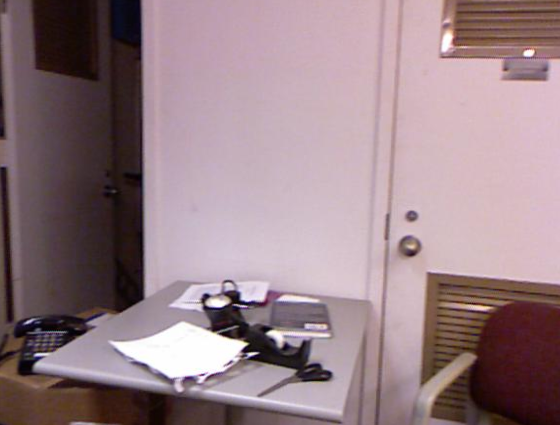

Question:	 what is on the right side of the black telephone and on the left side of the red chair
Answer:		 desk (Label: 160)


In [147]:
def show_example(train=True, idx=None):
    dataset_type = "train" if train else "test"
    data = dataset[dataset_type]

    if idx is None:
        idx = np.random.randint(len(data))

    image_path = (
       f"{root_path}/images/"
        + f"{data[idx]['image_id']}.png"
    )
    image = Image.open(image_path)
    display.display(image)

    question = data[idx]["question"]
    answer = data[idx]["answer"]
    label = data[idx]["label"]

    print(f"Question:\t {question}")
    print(f"Answer:\t\t {answer} (Label: {label})")

show_example(idx=0)

<Axes: >

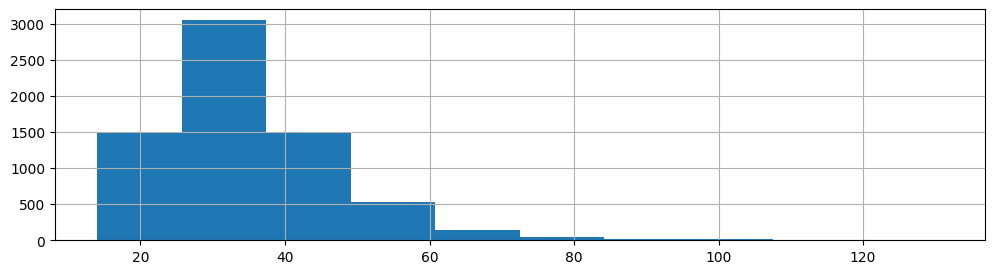

In [148]:
plt.figure(figsize=(12,3))
df_train["question"].apply(len).hist()

<Axes: >

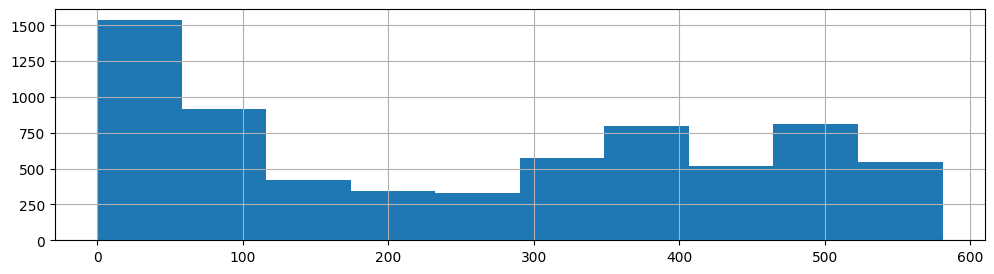

In [149]:
plt.figure(figsize=(12, 3))
df_train["label"].hist()

In [150]:
counts = df_train["label"].value_counts().sort_values(ascending=False)
counts.index = [answer_space[i] for i in counts.index]
counts.head(n=10)

2          272
table      235
chair      207
3          184
lamp       173
white      165
window     146
picture    146
photo      142
1          137
Name: count, dtype: int64

In [151]:
counts = df_train["label"].value_counts().sort_values(ascending=True)
counts.index = [answer_space[i] for i in counts.index]
counts.head(n=200) # very few samples

jeans                1
dog_cage             1
toothbrush_holder    1
fruit_basket         1
file_holder          1
                    ..
radiator             2
bread                2
vessel               2
dog_bed              2
certificate          2
Name: count, Length: 200, dtype: int64

In [152]:
counts = df_train["label"].value_counts().sort_values(ascending=True)
counts.index = [answer_space[i] for i in counts.index]
target_labels = [str(i) for i in range(16)]
filtered_counts = counts.reindex(target_labels, fill_value=0)

filtered_counts

0       0
1     137
2     272
3     184
4     111
5      44
6      59
7      28
8      32
9       6
10     16
11      9
12      2
13      0
14      4
15      1
Name: count, dtype: int64

In [153]:
counts = df_train["label"].value_counts().sort_values(ascending=True)

In [154]:
MAX_INPUT_LENGTH = df_train["question"].apply(len).max()

In [155]:
bert_input = bert_processor(
    "what is",
    max_length=MAX_INPUT_LENGTH,
    padding="max_length",
    return_tensors="pt",
    device=device,
)

{k:bert_input[k].shape for k in bert_input.keys()}

{'input_ids': torch.Size([1, 131]),
 'token_type_ids': torch.Size([1, 131]),
 'attention_mask': torch.Size([1, 131])}

In [156]:
image_path = f"{root_path}/images/" + f"{df_train.iloc[0]['image_id']}.png"
dino_input = dino_processor(image_path, return_tensors="pt", device=device)

{k: dino_input[k].shape for k in dino_input.keys()}

{'pixel_values': torch.Size([1, 3, 224, 224])}

## Dataset

In [157]:
dino_cache = {}
dino_model.eval()
batch_size = 32

unique_ids = df_train["image_id"].unique()

with torch.no_grad():
    for i in tqdm(range(0, len(unique_ids), batch_size), desc="Caching Train Features"):
        batch_ids = unique_ids[i : i + batch_size]

        images = [
            Image.open(f"{root_path}/images/{img_id}.png").convert("RGB")
            for img_id in batch_ids
        ]

        inputs = dino_processor(images=images, return_tensors="pt").to(device)
        outputs = dino_model(**inputs)

        # Extract all patches, excluding the CLS token (index 0)
        # Shape: (Batch, Num_Patches, Hidden_Dim)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :].detach().cpu()

        for idx, img_id in enumerate(batch_ids):
            dino_cache[img_id] = {"patches": patch_embeddings[idx]}

Caching Train Features: 100%|██████████| 25/25 [00:09<00:00,  2.73it/s]


In [158]:
class DAQUARDataset(Dataset):
    def __init__(self, df, dino_cache):
        self.df = df
        self.dino_cache = dino_cache

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text_inputs = bert_processor(
            row["question"],
            max_length=MAX_INPUT_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        dino_embd = self.dino_cache[row["image_id"]]["patches"]

        label = torch.tensor(row["label"], dtype=torch.long)

        return {
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "dino_embd": dino_embd,
            "label": label,
        }

    def __len__(self):
        return len(self.df)

In [159]:
counts = df_train["label"].value_counts()
df_train = df_train[df_train["label"].isin(counts[counts > 6].index)]
len(df_train)

6110

In [160]:
n_classes = df_train["label"].nunique()
n_classes

160

In [161]:
# create a mapping from original label to contiguous index
unique_labels = sorted(df_train["label"].unique())
label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}

# apply the mapping
df_train["label"] = df_train["label"].map(label_map)

# update n_classes to match the filtered set
n_classes = len(unique_labels)
print(n_classes)

# create a filtered answer space for the WUPS metric
answer_space = [answer_space[old_idx] for old_idx in unique_labels]

160


In [162]:
train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=seed, stratify=df_train["label"])

train_ds = DAQUARDataset(train_df, dino_cache)
val_ds = DAQUARDataset(val_df, dino_cache)

train_loader = DataLoader(train_ds, shuffle=True, batch_size=32)
val_loader = DataLoader(val_ds, shuffle=True, batch_size=32)

In [163]:
batch = next(iter(train_loader))

{k: batch[k].shape for k in batch.keys()}

{'input_ids': torch.Size([32, 131]),
 'attention_mask': torch.Size([32, 131]),
 'dino_embd': torch.Size([32, 200, 768]),
 'label': torch.Size([32])}

In [164]:
train_df["label"].describe()

count    4888.000000
mean       73.676964
std        51.725988
min         0.000000
25%        24.000000
50%        74.000000
75%       120.000000
max       159.000000
Name: label, dtype: float64

# Model

In [534]:
class VQAModel(nn.Module):
    def __init__(self, text_dim=768, vision_dim=768, hidden_dim=64):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.vision_proj = nn.Linear(vision_dim, hidden_dim)

        # Cross-Attention: Question attends to Patches
        self.cross_attn = nn.MultiheadAttention(
            hidden_dim, num_heads=8, batch_first=True, dropout=0.1
        )
        self.ln_attn = nn.LayerNorm(hidden_dim)

        # FiLM to refine the fused representation
        self.film = nn.Linear(hidden_dim, hidden_dim * 2)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),  # GELU often performs better than ReLU for VQA
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, input_ids, attention_mask, dino_embd, **kwargs):
        with torch.no_grad():
            bert_out = bert_model(
                input_ids, attention_mask=attention_mask
            ).last_hidden_state
            q_cls = bert_out[:, 0, :]  # (B, 768)

        if self.training:
            dino_embd = dino_embd + torch.randn_like(dino_embd) * 0.03

        # Project question to hidden_dim
        q_feat_sq = self.text_proj(q_cls)  # (B, H)
        q_feat_3d = q_feat_sq.unsqueeze(1)  # (B, 1, H)

        # Project vision to hidden_dim
        v_feat = self.vision_proj(dino_embd)  # (B, N, H)

        # 1. Cross-Attention: Question (Query) attends to Image Patches (Key/Value)
        # attn_out shape: (B, 1, H)
        attn_out, _ = self.cross_attn(q_feat_3d, v_feat, v_feat)

        # 2. Residual Connection + LayerNorm
        # Squeeze attn_out back to (B, H)
        fused = self.ln_attn(attn_out.squeeze(1) + q_feat_sq)

        # 3. FiLM Modulation
        params = self.film(q_feat_sq)  # (B, 2H)
        gamma, beta = torch.chunk(params, 2, dim=-1)
        fused = (gamma * fused) + beta

        return self.classifier(fused)

In [535]:
def to_cuda(batch):
    return {k: batch[k].to(device) for k in batch.keys()}

In [536]:
model = VQAModel().to(device)

model(**to_cuda(batch)).shape

torch.Size([15, 160])

In [537]:
print(f"{sum(p.numel() for p in model.parameters()):_}")

138_080


# Training

In [538]:
class WUPS(tm.Metric):
    def __init__(self, vocab, threshold=0.9, dist_sync_on_step=False):
        super().__init__(dist_sync_on_step=dist_sync_on_step)
        self.vocab = vocab
        self.threshold = threshold
        self.add_state("sum_wups", default=torch.tensor(0.0), dist_reduce_fx="sum")
        self.add_state("total", default=torch.tensor(0), dist_reduce_fx="sum")

        sim_matrix = self._precompute_matrix(vocab)
        self.register_buffer("sim_matrix", sim_matrix)

    def _get_wup_sim(self, word1, word2):
        if word1 == word2:
            return 1.0
        s1 = wn.synsets(word1)
        s2 = wn.synsets(word2)
        if not s1 or not s2:
            return 0.0

        sim = 0.0
        for syn1 in s1:
            for syn2 in s2:
                cur_sim = syn1.wup_similarity(syn2) or 0.0
                sim = max(sim, cur_sim)

        return sim if sim >= self.threshold else 0.1 * sim

    def _precompute_matrix(self, vocab):
        v = len(vocab)
        matrix = torch.zeros((v, v))
        for i in tqdm(range(v)):
            for j in range(i, v):
                sim = self._get_wup_sim(vocab[i], vocab[j])
                matrix[i, j] = sim
                matrix[j, i] = sim
        return matrix

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        if preds.ndim > 1:
            preds = torch.argmax(preds, dim=-1)

        scores = self.sim_matrix[preds, target]

        self.sum_wups += torch.sum(scores)
        self.total += target.size(0)

    def compute(self):
        return self.sum_wups / self.total

wups = WUPS(vocab=answer_space).to(device)

100%|██████████| 160/160 [00:17<00:00,  8.97it/s]


In [539]:
best_metric = -float('inf')

In [540]:
lr = 3e-4
epochs = 50 # after 20 epochs it highly overfits

counts = train_df["label"].value_counts().sort_index().values

weights = 1.0 / (counts**0.5)
weights = weights / weights.sum() * len(counts)
criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(weights).to(device), label_smoothing=0.2
)

optimizer = torch.optim.AdamW(model.parameters(), lr, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [541]:
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0

    for batch in tqdm(train_loader):
        batch = to_cuda(batch)

        out = model(**batch)
        loss = criterion(out, batch["label"])

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    wups.reset()
    val_running_loss = 0

    for batch in tqdm(val_loader):
        batch = to_cuda(batch)

        with torch.no_grad():
            out = model(**batch)
            wups(out, batch["label"])
            loss = criterion(out, batch["label"])

        val_running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    avg_val_loss = val_running_loss / len(val_loader)
    wups_metric = wups.compute()
    if best_metric < wups_metric:
        best_metric = wups_metric
        if best_metric > 0.33:
            torch.save(model.state_dict(), "model.pth")
        print("new best!")
    scheduler.step()
    print(f"epoch {epoch}: loss={avg_loss:.3f}, val_loss={avg_val_loss:.3f}, wups={wups_metric:.3f}")

100%|██████████| 39/39 [00:02<00:00, 13.51it/s]


new best!
epoch 1: loss=5.746, val_loss=5.650, wups=0.148


100%|██████████| 39/39 [00:02<00:00, 16.36it/s]


new best!
epoch 2: loss=5.551, val_loss=5.441, wups=0.220


100%|██████████| 39/39 [00:02<00:00, 16.38it/s]


...

epoch 48: loss=4.094, val_loss=4.792, wups=0.339


100%|██████████| 39/39 [00:02<00:00, 14.10it/s]


epoch 49: loss=4.089, val_loss=4.772, wups=0.337


100%|██████████| 39/39 [00:02<00:00, 13.66it/s]

epoch 50: loss=4.097, val_loss=4.808, wups=0.337


In [553]:
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

## Evaluation

In [554]:
# %%
def visualize_prediction(idx=None, use_train=False):
    model.eval()
    # Select the dataframe subset
    df_subset = train_df if use_train else val_df

    if idx is None:
        idx = np.random.randint(len(df_subset))

    row = df_subset.iloc[idx]
    image_id = row["image_id"]
    question = row["question"]
    gt_label = row["label"]
    gt_answer = answer_space[gt_label]

    # Process text inputs
    text_inputs = bert_processor(
        question,
        max_length=MAX_INPUT_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).to(device)

    # Retrieve cached visual embeddings
    dino_embd = dino_cache[image_id]["patches"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        logits = model(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs["attention_mask"],
            dino_embd=dino_embd,
        )
        pred_idx = logits.argmax(dim=-1).item()
        pred_answer = answer_space[pred_idx]

    # Retrieve WUPS score from precomputed similarity matrix
    # The matrix is indexed by [prediction_index, ground_truth_index]
    wups_score = wups.sim_matrix[pred_idx, gt_label].item()

    # Visualization
    image_path = f"{root_path}/images/{image_id}.png"
    display.display(Image.open(image_path))

    print(f"Question:      {question}")
    print(f"Ground Truth:  {gt_answer} (Label: {gt_label})")
    print(f"Prediction:    {pred_answer} (Label: {pred_idx})")
    print(f"WUPS Score:    {wups_score:.4f}")

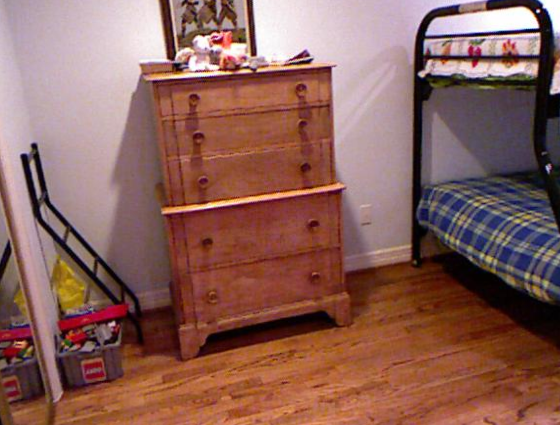

Question:      what is the object on the floor in front of the wall
Ground Truth:  cabinet (Label: 34)
Prediction:    cabinet (Label: 34)
WUPS Score:    1.0000


In [555]:
visualize_prediction()

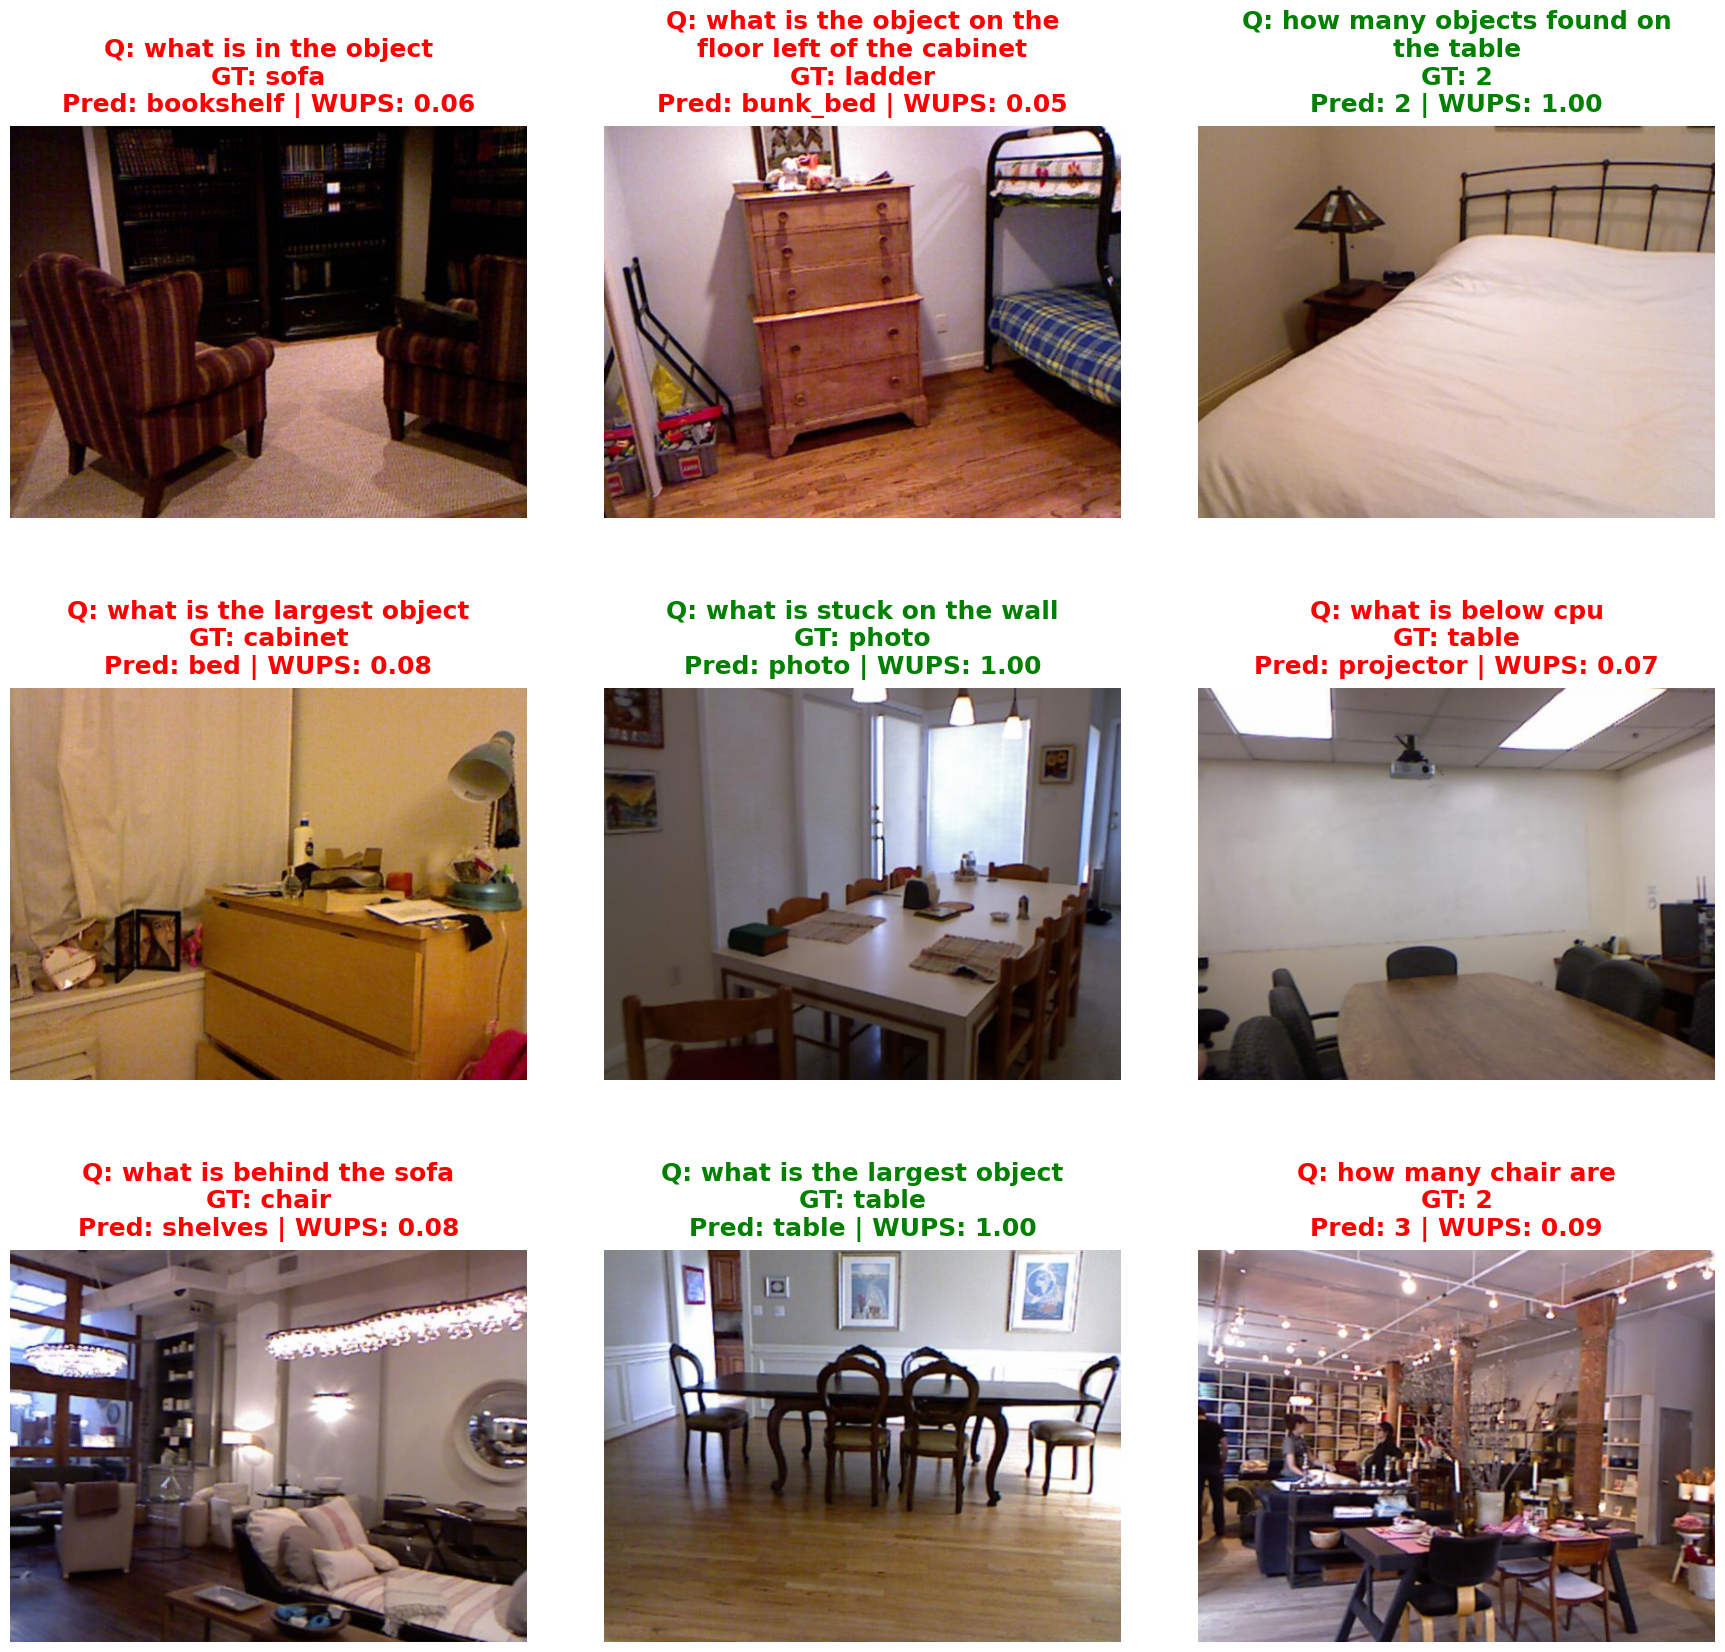

In [577]:
import textwrap


def show_collage_3x3(df_subset):
    model.eval()
    indices = np.random.choice(len(df_subset), 9, replace=False)

    # Adjusted figsize for better vertical density
    fig, axes = plt.subplots(3, 3, figsize=(22, 20))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        row = df_subset.iloc[idx]
        image_id = row["image_id"]
        question = row["question"]
        gt_label = row["label"]
        gt_answer = answer_space[gt_label]

        text_inputs = bert_processor(
            question,
            max_length=MAX_INPUT_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).to(device)

        dino_embd = dino_cache[image_id]["patches"].unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(
                input_ids=text_inputs["input_ids"],
                attention_mask=text_inputs["attention_mask"],
                dino_embd=dino_embd,
            )
            pred_idx = logits.argmax(dim=-1).item()
            pred_answer = answer_space[pred_idx]
            wups_score = wups.sim_matrix[pred_idx, gt_label].item()

        image_path = f"{root_path}/images/{image_id}.png"
        img = Image.open(image_path)

        ax = axes[i]
        ax.imshow(img)
        ax.axis("off")

        # Narrower wrapping to accommodate much larger font
        wrapped_q = "\n".join(textwrap.wrap(f"Q: {question}", width=30))
        color = (
            "green" if pred_idx == gt_label else "orange" if wups_score > 0.5 else "red"
        )

        # Significantly larger text
        ax.set_title(
            f"{wrapped_q}\nGT: {gt_answer}\nPred: {pred_answer} | WUPS: {wups_score:.2f}",
            fontsize=18,
            fontweight="bold",
            color=color,
            pad=10,
        )

    # hspace controls the vertical gap between rows
    plt.subplots_adjust(wspace=0.15, hspace=0.35)
    plt.show()


show_collage_3x3(val_df)

# Submission

In [565]:
test_root_path = "/home/stefan/ioai-prep/kits/rooms"
df_test = pd.read_csv(f"{test_root_path}/test.csv")

In [566]:
dino_cache_test = {}
dino_model.eval()
batch_size = 32

test_unique_ids = df_test["image_id"].unique()

with torch.no_grad():
    for i in tqdm(
        range(0, len(test_unique_ids), batch_size), desc="Caching Test Features"
    ):
        batch_ids = test_unique_ids[i : i + batch_size]

        images = [
            Image.open(f"{test_root_path}/images/{img_id}.png").convert("RGB")
            for img_id in batch_ids
        ]

        inputs = dino_processor(images=images, return_tensors="pt").to(device)
        outputs = dino_model(**inputs)

        # Shape: (Batch, Num_Patches, Hidden_Dim)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :].detach().cpu()

        for idx, img_id in enumerate(batch_ids):
            dino_cache_test[img_id] = {"patches": patch_embeddings[idx]}

Caching Test Features:   0%|          | 0/10 [00:00<?, ?it/s]

Caching Test Features: 100%|██████████| 10/10 [00:03<00:00,  2.82it/s]


In [567]:
class RoomsTestDataset(Dataset):
    def __init__(self, df, dino_cache):
        self.df = df
        self.dino_cache = dino_cache

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text_inputs = bert_processor(
            row["question"],
            max_length=MAX_INPUT_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        dino_embd = self.dino_cache[row["image_id"]]["patches"]

        return {
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "dino_embd": dino_embd,
        }

    def __len__(self):
        return len(self.df)

In [568]:
test_ds = RoomsTestDataset(df_test, dino_cache_test)
test_loader = DataLoader(test_ds, shuffle=False, batch_size=32)

In [569]:
model.eval()
predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Running Inference"):
        batch = to_cuda(batch)
        outputs = model(**batch)
        preds = outputs.argmax(dim=-1).cpu().tolist()
        predictions.extend(preds)

Running Inference:   0%|          | 0/12 [00:00<?, ?it/s]

Running Inference: 100%|██████████| 12/12 [00:00<00:00, 14.57it/s]


In [570]:
final_answers = []
for p in predictions:
    ans_str = answer_space[p]

    if ans_str.isdigit():
        final_answers.append(int(ans_str))
    else:
        final_answers.append(2)

# Create submission dataframe
submission_df = pd.DataFrame(
    {"sample_id": df_test["sample_id"], "answer": final_answers}
)

submission_df.to_csv(f"{test_root_path}/submission.csv", index=False)
submission_df.head()

,sample_id,answer
0,TEST0000,4
1,TEST0001,1
2,TEST0002,2
3,TEST0003,6
4,TEST0004,3


In [571]:
submission_df["answer"].describe()

count    367.000000
mean       2.795640
std        1.402255
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        8.000000
Name: answer, dtype: float64